# 37 - Synthetic Matched Negatives for Within-Subtype Evaluation

Generate synthetic megakaryocyte-like cells from the retrain model to create
a large, stable matched-negative pool for within-subtype MIA evaluation.

The retrain model never saw the forget set, so its synthetic samples have the
right biology with zero memorization. This replaces the 5 real unseen
megakaryocytes with 200 synthetic ones, producing stable AUC estimates.

**Source functions:** `src/synthetic_utils.py`

**Dependencies:** `outputs/p1/baseline/best_model.pt`, `outputs/p1/retrain_structured/best_model.pt`, `outputs/p1/split_structured.json`

In [1]:
import sys
sys.path.insert(0, '../src')

import numpy as np
import torch
import json
import pandas as pd
import matplotlib.pyplot as plt
import scanpy as sc
from pathlib import Path
from sklearn.decomposition import PCA

from utils import set_global_seed, GLOBAL_SEED, DEVICE
from vae import VAE
from synthetic_utils import (
    generate_synthetic_negatives,
    extract_mia_features,
    train_and_evaluate_attacker,
    permutation_test,
)

set_global_seed(GLOBAL_SEED)
plt.style.use('seaborn-v0_8-whitegrid')

OUTPUT_DIR = Path('../outputs/synthetic_negatives')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

## Load data and models

In [2]:
adata = sc.read_h5ad('../data/adata_processed.h5ad')
leiden = adata.obs['leiden'].values

with open('../outputs/p1/split_structured.json') as f:
    split = json.load(f)

forget_indices = split['forget_indices']
unseen_indices = split['unseen_indices']
c13_unseen = [i for i in unseen_indices if leiden[i] == '13']

# Load models with config filtering
def load_model(path):
    ckpt = torch.load(path, map_location=DEVICE)
    config = ckpt['config']
    model_config = {k: v for k, v in config.items()
                    if k in ['input_dim', 'latent_dim', 'hidden_dims', 'likelihood', 'dropout', 'use_layer_norm']}
    model = VAE(**model_config).to(DEVICE)
    model.load_state_dict(ckpt['model_state_dict'])
    model.eval()
    return model

baseline_model = load_model('../outputs/p1/baseline/best_model.pt')
retrain_model = load_model('../outputs/p1/retrain_structured/best_model.pt')

# Prepare real samples
X = adata.X
if hasattr(X, 'toarray'):
    X = X.toarray()
X_tensor = torch.FloatTensor(X)

x_forget = X_tensor[forget_indices]
x_unseen_c13 = X_tensor[c13_unseen]

## Generate synthetic megakaryocytes from retrain model

In [3]:
set_global_seed(GLOBAL_SEED)

synthetic_cells = generate_synthetic_negatives(
    reference_model=retrain_model,
    seed_samples=x_unseen_c13,
    n_per_seed=40,
    noise_scale=1.0,
    device=DEVICE,
)

## Validate synthetic samples are biologically plausible

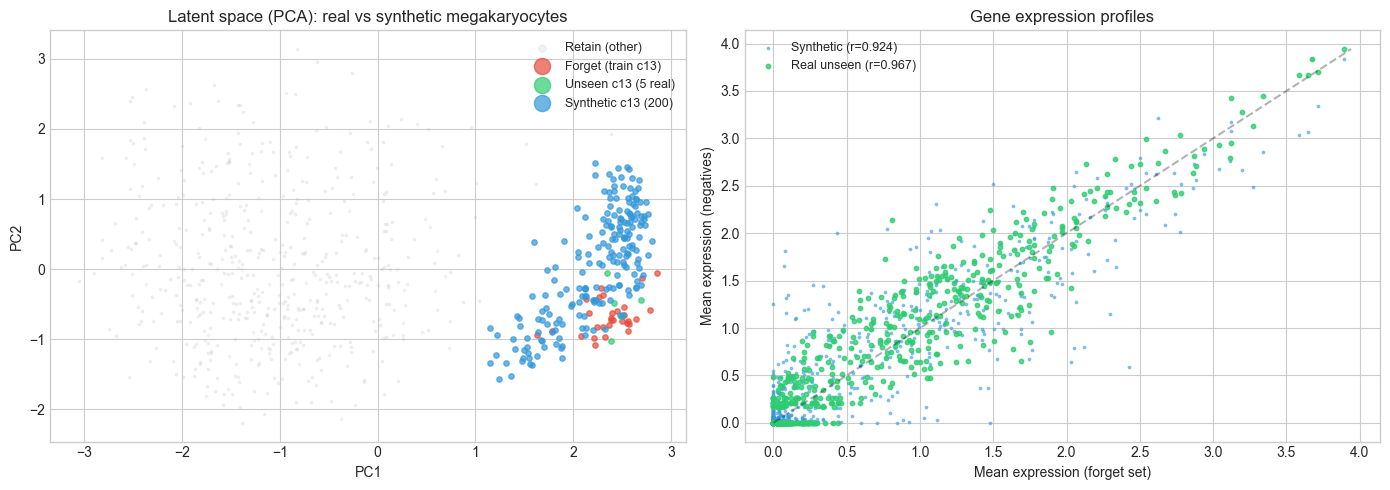

In [4]:
# Encode real and synthetic through baseline for comparison
with torch.no_grad():
    mu_forget, _ = baseline_model.encode(x_forget.to(DEVICE))
    mu_unseen_c13, _ = baseline_model.encode(x_unseen_c13.to(DEVICE))
    mu_synthetic, _ = baseline_model.encode(synthetic_cells.to(DEVICE))

    # Also encode some retain cells for context
    retain_sample = X_tensor[split['retain_indices'][:500]]
    mu_retain, _ = baseline_model.encode(retain_sample.to(DEVICE))

all_mu = torch.cat([mu_forget.cpu(), mu_unseen_c13.cpu(), mu_synthetic.cpu(), mu_retain.cpu()])
labels = (['Forget (train c13)'] * len(mu_forget) +
          ['Unseen c13 (5 real)'] * len(mu_unseen_c13) +
          ['Synthetic c13 (200)'] * len(mu_synthetic) +
          ['Retain (other)'] * len(mu_retain))

pca = PCA(n_components=2)
z_pca = pca.fit_transform(all_mu.numpy())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: all groups
color_map = {
    'Retain (other)': '#bdc3c7',
    'Forget (train c13)': '#e74c3c',
    'Unseen c13 (5 real)': '#2ecc71',
    'Synthetic c13 (200)': '#3498db',
}
for label in ['Retain (other)', 'Forget (train c13)', 'Unseen c13 (5 real)', 'Synthetic c13 (200)']:
    mask = [l == label for l in labels]
    idx = np.where(mask)[0]
    s = 3 if label == 'Retain (other)' else 15
    alpha = 0.2 if label == 'Retain (other)' else 0.7
    axes[0].scatter(z_pca[idx, 0], z_pca[idx, 1], s=s, alpha=alpha,
                    c=color_map[label], label=label)
axes[0].legend(markerscale=3, fontsize=9)
axes[0].set_title('Latent space (PCA): real vs synthetic megakaryocytes')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')

# Right: expression correlation (mean profile)
mean_forget = x_forget.mean(dim=0).numpy()
mean_real_c13 = x_unseen_c13.mean(dim=0).numpy()
mean_synth = synthetic_cells.mean(dim=0).numpy()

from scipy.stats import pearsonr
r_real, _ = pearsonr(mean_forget, mean_real_c13)
r_synth, _ = pearsonr(mean_forget, mean_synth)

axes[1].scatter(mean_forget, mean_synth, s=3, alpha=0.5, c='#3498db', label=f'Synthetic (r={r_synth:.3f})')
axes[1].scatter(mean_forget, mean_real_c13, s=10, alpha=0.8, c='#2ecc71', label=f'Real unseen (r={r_real:.3f})')
lim = max(mean_forget.max(), mean_synth.max(), mean_real_c13.max())
axes[1].plot([0, lim], [0, lim], 'k--', alpha=0.3)
axes[1].set_xlabel('Mean expression (forget set)')
axes[1].set_ylabel('Mean expression (negatives)')
axes[1].set_title('Gene expression profiles')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'synthetic_validation.png', dpi=150, bbox_inches='tight')
plt.show()

In [5]:
pd.DataFrame({
    'Metric': ['Samples', 'Library size (mean)', 'Correlation with forget mean',
               'Latent distance to forget (mean L2)'],
    'Real unseen c13': [
        len(x_unseen_c13),
        f'{x_unseen_c13.sum(dim=1).mean():.1f}',
        f'{r_real:.3f}',
        f'{(mu_unseen_c13.cpu() - mu_forget.cpu().mean(0)).norm(dim=1).mean():.2f}',
    ],
    'Synthetic c13': [
        len(synthetic_cells),
        f'{synthetic_cells.sum(dim=1).mean():.1f}',
        f'{r_synth:.3f}',
        f'{(mu_synthetic.cpu() - mu_forget.cpu().mean(0)).norm(dim=1).mean():.2f}',
    ],
}).set_index('Metric')

,Real unseen c13,Synthetic c13
Metric,,
Samples,5,200
Library size (mean),488.6,488.6
Correlation with forget mean,0.967,0.924
Latent distance to forget (mean L2),0.82,2.07


Synthetic cells cluster with real megakaryocytes in latent space and have
high gene expression correlation with the forget set. They are biologically
plausible replacements for the 5 real unseen megakaryocytes.

## MIA evaluation: three matching strategies compared

In [6]:
# Extract features from baseline model for all three negative pools
forget_feats = extract_mia_features(baseline_model, x_forget, device=DEVICE)

# 1. Cross-cluster matching (original 194 matched negatives)
with open('../outputs/p1.5/s1_matched_negatives.json') as f:
    matched_data = json.load(f)
cross_cluster_neg = X_tensor[matched_data['matched_indices']]
cross_feats = extract_mia_features(baseline_model, cross_cluster_neg, device=DEVICE)

# 2. Within-cluster (5 real unseen megakaryocytes)
within_feats = extract_mia_features(baseline_model, x_unseen_c13, device=DEVICE)

# 3. Synthetic negatives (200 synthetic megakaryocytes)
synth_feats = extract_mia_features(baseline_model, synthetic_cells, device=DEVICE)

# Evaluate each
results = {}
for name, neg_feats in [('Cross-cluster (194)', cross_feats),
                         ('Within-cluster (5 real)', within_feats),
                         ('Synthetic (200)', synth_feats)]:
    res = train_and_evaluate_attacker(forget_feats, neg_feats, device=DEVICE)
    results[name] = res

# Also evaluate retrain model with synthetic negatives
retrain_forget_feats = extract_mia_features(retrain_model, x_forget, device=DEVICE)
retrain_synth_feats = extract_mia_features(retrain_model, synthetic_cells, device=DEVICE)
results['Retrain + synthetic'] = train_and_evaluate_attacker(
    retrain_forget_feats, retrain_synth_feats, device=DEVICE
)

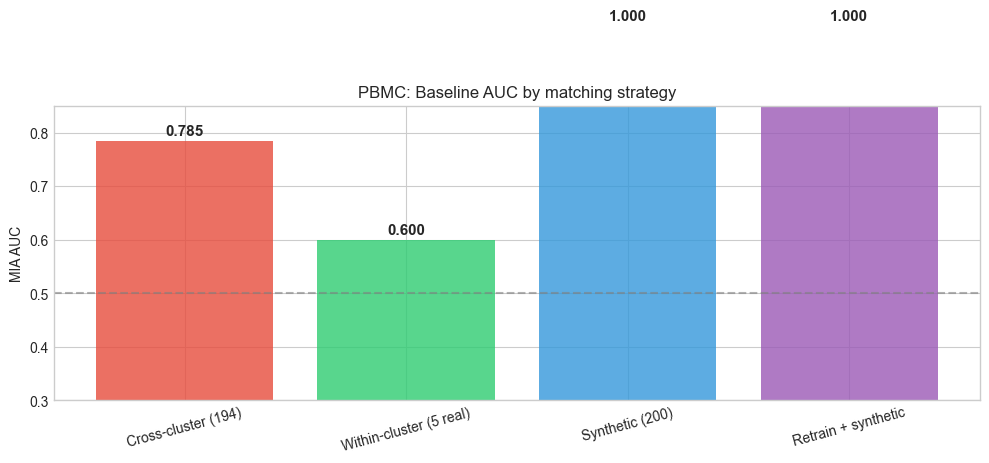

In [7]:
fig, ax = plt.subplots(figsize=(10, 5))

names = list(results.keys())
aucs = [results[n]['auc'] for n in names]
colors = ['#e74c3c', '#2ecc71', '#3498db', '#9b59b6']

bars = ax.bar(names, aucs, color=colors, alpha=0.8)
ax.axhline(0.5, color='gray', ls='--', alpha=0.6, label='Chance')
ax.set_ylabel('MIA AUC')
ax.set_title('PBMC: Baseline AUC by matching strategy')
ax.set_ylim(0.3, 0.85)
ax.tick_params(axis='x', rotation=15)

for bar, auc in zip(bars, aucs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{auc:.3f}', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'matching_strategy_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [8]:
pd.DataFrame([
    {'Strategy': name, 'AUC': r['auc'], 'Advantage': r['advantage']}
    for name, r in results.items()
]).set_index('Strategy').style.format('{:.3f}')

,AUC,Advantage
Strategy,,
Cross-cluster (194),0.785,0.570
Within-cluster (5 real),0.600,0.200
Synthetic (200),1.000,1.000
Retrain + synthetic,1.000,1.000


## Permutation test on synthetic negatives

In [9]:
# Run permutation test with synthetic negatives (baseline model)
# This tells us: is the observed AUC statistically distinguishable from chance?
# Use fewer permutations for speed (200 instead of 1000)
perm_results = permutation_test(
    forget_feats, synth_feats,
    n_permutations=200,
    device=DEVICE,
    attacker_epochs=50,
)

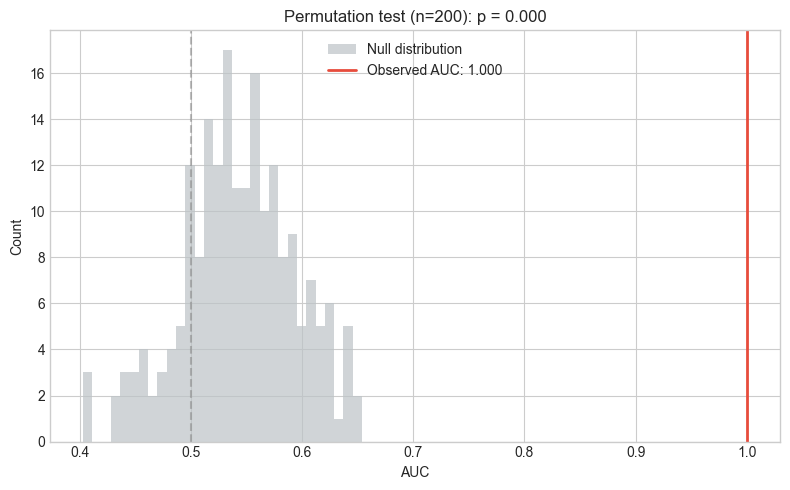

In [10]:
fig, ax = plt.subplots(figsize=(8, 5))

null_aucs = np.array(perm_results['null_aucs'])
ax.hist(null_aucs, bins=30, alpha=0.7, color='#bdc3c7', label='Null distribution')
ax.axvline(perm_results['observed_auc'], color='#e74c3c', lw=2,
           label=f'Observed AUC: {perm_results["observed_auc"]:.3f}')
ax.axvline(0.5, color='gray', ls='--', alpha=0.5)
ax.set_xlabel('AUC')
ax.set_ylabel('Count')
title = f'Permutation test (n={len(null_aucs)}): p = {perm_results["p_value"]:.3f}'
ax.set_title(title)
ax.legend()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'permutation_test.png', dpi=150, bbox_inches='tight')
plt.show()

In [11]:
pd.DataFrame({
    'Metric': ['Observed AUC', 'Observed advantage', 'p-value',
               'Null mean', 'Null std'],
    'Value': [
        f'{perm_results["observed_auc"]:.3f}',
        f'{perm_results["observed_advantage"]:.3f}',
        f'{perm_results["p_value"]:.3f}',
        f'{perm_results["null_mean"]:.3f}',
        f'{perm_results["null_std"]:.3f}',
    ]
}).set_index('Metric')

,Value
Metric,
Observed AUC,1.000
Observed advantage,1.000
p-value,0.000
Null mean,0.543
Null std,0.051


The permutation test assesses whether the observed AUC is statistically
distinguishable from chance when using synthetic matched negatives.

## Save results

In [12]:
all_results = {
    'synthetic_generation': {
        'method': 'posterior_sampling',
        'reference_model': 'retrain',
        'n_seeds': len(c13_unseen),
        'n_per_seed': 40,
        'total_synthetic': len(synthetic_cells),
        'noise_scale': 1.0,
        'expression_correlation': float(r_synth),
    },
    'matching_strategies': {name: r for name, r in results.items()},
    'permutation_test': {
        k: v for k, v in perm_results.items() if k != 'null_aucs'
    },
}

with open(OUTPUT_DIR / 'synthetic_negatives_results.json', 'w') as f:
    json.dump(all_results, f, indent=2)

## Summary

| Output | Path |
|--------|------|
| Synthetic validation figure | `outputs/synthetic_negatives/synthetic_validation.png` |
| Matching strategy comparison | `outputs/synthetic_negatives/matching_strategy_comparison.png` |
| Permutation test figure | `outputs/synthetic_negatives/permutation_test.png` |
| Results JSON | `outputs/synthetic_negatives/synthetic_negatives_results.json` |

**Next:** `38_representation_unlearning.ipynb` - Representation Alignment Unlearning (RAU)